# E0: 一般化Boole写像の理論整合性確認

## tl;dr

`alpha = 0.4, 0.5, 0.6`、各5 seed、各10万観測点で検証し、総合判定は **PASS** だった。尺度の最大相対誤差は `0.013948`、Lyapunov指数の最大絶対誤差は `0.001175`、KS距離最大値は `0.006502`、非零TMモードの最大絶対値は `0.007621` だった。

この結果は、一般化Boole写像をCauchy可解モデルとして実装するE0基盤を支持する。ただし、結合系の同期、情報保持、一般のTM基底の有効性はまだ検証していない。

## Context & Methods

### 研究質問

一般化Boole写像

$$F_\alpha(x)=\alpha\left(x-\frac{1}{x}\right),\qquad 0<\alpha<1$$

について、次の理論値を有限精度・有限長軌道で再現できるかを確認する。

$$\gamma_\alpha=\sqrt{\frac{\alpha}{1-\alpha}},\qquad\lambda(\alpha)=2\log(\sqrt{\alpha}+\sqrt{1-\alpha})$$

Cayleyモードは

$$q_\gamma(x)=\frac{x-i\gamma}{x+i\gamma},\qquad M_k(x)=q_\gamma(x)^k$$

とし、中心0・尺度$\gamma$のCauchy測度では非零次数の期待値が0になることを検証する。

### Key Assumptions

- 初期値は理論Cauchy測度から生成する。
- 四分位幅からCauchy尺度を推定し、平均・分散は使わない。
- KS距離は理論尺度に対して計算する。
- TM検証は簡略化したCayleyモードに限定する。
- 合格閾値は統計的有意水準ではなく、実装回帰を検出する事前定義ゲートである。

### Source

実験コード: `e0_boole_validation.py`  
原典: `../../../研究テーマ探索/参考文献/Infinite Dimensional Chaotic Synchronization for Randomly Coupling Systems and Dynamical Phase Transition.pdf`

## Data

### 1. 保存済み実験結果を読み込む

In [1]:
from __future__ import annotations

import csv
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RUN_DIRECTORY = Path.cwd()
ARTIFACTS_DIRECTORY = RUN_DIRECTORY / 'artifacts'
summary = json.loads((ARTIFACTS_DIRECTORY / 'summary.json').read_text(encoding='utf-8'))
with (ARTIFACTS_DIRECTORY / 'per_seed_metrics.csv').open(encoding='utf-8-sig', newline='') as stream:
    per_seed_rows = list(csv.DictReader(stream))

print(f"alpha数: {len(summary['per_alpha'])}")
print(f"seed別行数: {len(per_seed_rows)}")
print(f"総合判定: {summary['overall_passed']}")

alpha数: 3
seed別行数: 15
総合判定: True


### 2. 入力件数と完全性を確認する

期待する粒度は `3 alpha × 5 seed = 15行`。各行は一つの決定論的軌道を表す。

In [2]:
expected_row_count = len(summary['config']['alpha_values']) * len(summary['config']['seeds'])
assert len(per_seed_rows) == expected_row_count
assert all(row['finite'].lower() == 'true' for row in per_seed_rows)
assert len({(row['alpha'], row['seed']) for row in per_seed_rows}) == expected_row_count
print({'expected_rows': expected_row_count, 'actual_rows': len(per_seed_rows), 'finite': True, 'duplicates': 0})

{'expected_rows': 15, 'actual_rows': 15, 'finite': True, 'duplicates': 0}


## Results

### 3. alpha別の主要指標

| alpha | 理論scale | scale最大相対誤差 | Lyapunov最大絶対誤差 | KS最大値 | TM非零最大値 | 判定 |
|---:|---:|---:|---:|---:|---:|:---:|
| 0.4 | 0.816497 | 0.013948 | 0.001175 | 0.006502 | 0.007621 | PASS |
| 0.5 | 1.000000 | 0.007904 | 0.000031 | 0.004497 | 0.004496 | PASS |
| 0.6 | 1.224745 | 0.007178 | 0.000810 | 0.005901 | 0.006524 | PASS |

In [3]:
for row in summary['per_alpha']:
    failed_gates = [name for name, passed in row['gates'].items() if not passed]
    print(f"alpha={row['alpha']:.1f}: passed={row['passed']}, failed_gates={failed_gates}")

alpha=0.4: passed=True, failed_gates=[]
alpha=0.5: passed=True, failed_gates=[]
alpha=0.6: passed=True, failed_gates=[]


### 4. seed別誤差を可視化する

**Analytical question:** 4つのseed別指標は、すべて事前定義ゲートを下回るか。  
**Takeaway:** 15軌道×4指標の全点がゲートを下回った。  
破線は事前定義した合格上限。対数軸を使い、小さい誤差の差を読みやすくする。

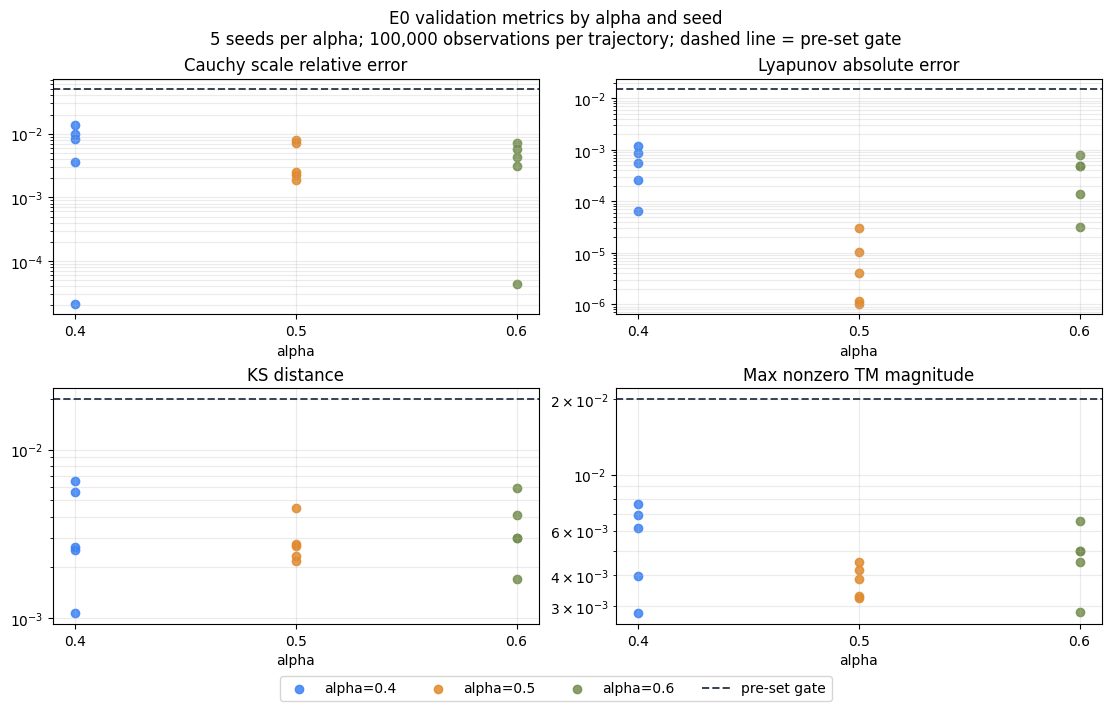

In [4]:
numeric_fields = ['scale_relative_error', 'lyapunov_absolute_error', 'ks_distance', 'tm_max_nonzero_magnitude']
metric_titles = ['Cauchy scale relative error', 'Lyapunov absolute error', 'KS distance', 'Max nonzero TM magnitude']
thresholds = [
    summary['config']['thresholds']['max_scale_relative_error'],
    summary['config']['thresholds']['max_lyapunov_absolute_error'],
    summary['config']['thresholds']['max_ks_distance'],
    summary['config']['thresholds']['max_tm_nonzero_magnitude'],
]
alphas = sorted({float(row['alpha']) for row in per_seed_rows})
palette = {0.4: '#3B82F6', 0.5: '#E28A2B', 0.6: '#758E4F'}
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
for axis, field, title, threshold in zip(axes.flat, numeric_fields, metric_titles, thresholds):
    for alpha in alphas:
        values = [float(row[field]) for row in per_seed_rows if float(row['alpha']) == alpha]
        axis.scatter([alpha] * len(values), values, label=f'alpha={alpha:.1f}', color=palette[alpha], alpha=0.85)
    axis.axhline(threshold, color='#374151', linestyle='--', linewidth=1.4, label='pre-set gate')
    axis.set_yscale('log')
    axis.set_title(title)
    axis.set_xlabel('alpha')
    axis.set_xticks(alphas)
    axis.grid(True, which='both', alpha=0.25)
fig.suptitle('E0 validation metrics by alpha and seed\n5 seeds per alpha; 100,000 observations per trajectory; dashed line = pre-set gate')
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=4)
fig.savefig(ARTIFACTS_DIRECTORY / 'e0_metric_gates.png', dpi=160, bbox_inches='tight')
plt.show()

### 5. 理論Lyapunov指数を独立な数値積分で照合する

Cauchy変数を角度座標へ変換した等確率積分を用い、軌道平均とは別経路で閉形式を確認する。

In [5]:
quadrature_rows = [
    {
        'alpha': row['alpha'],
        'closed_form': row['theoretical_lyapunov'],
        'quadrature': row['quadrature_lyapunov'],
        'absolute_error': row['quadrature_lyapunov_error'],
    }
    for row in summary['per_alpha']
]
quadrature_rows

[{'alpha': 0.4,
  'closed_form': 0.6829937571270775,
  'quadrature': 0.6829868256552716,
  'absolute_error': 6.931471805970979e-06},
 {'alpha': 0.5,
  'closed_form': 0.6931471805599454,
  'quadrature': 0.6931402490881394,
  'absolute_error': 6.931471805970979e-06},
 {'alpha': 0.6,
  'closed_form': 0.6829937571270775,
  'quadrature': 0.6829868256552716,
  'absolute_error': 6.931471805970979e-06}]

## Takeaways

1. 検証した3つの`alpha`では、有限軌道の経験分布が理論Cauchy測度と事前ゲート内で整合した。
2. 軌道平均と独立な角度積分の両方が、閉形式Lyapunov指数と整合した。
3. 非零Cayleyモードの平均は0近傍となり、E1AでTM特徴を実装するための最小チェックを通過した。
4. これは各ノードへ一般化Boole写像を置く数学的実装基盤を支持するが、複数ノードを結合する有用性は示していない。

### Caveats

- 簡略Cayleyモードの検証であり、一般のTakenaka–Malmquist基底全体の完全性や読み出し性能を保証しない。
- 初期値を不変測度から生成している。非定常初期値からの収束速度は別実験が必要である。
- 観測区間に厳密な浮動小数点重複はなかったが、より長時間の周期化を否定しない。
- 結合系の同期臨界式と入力情報保持は未検証である。

### Next Step

E1Aでは、独立な一般化Boole軌道の線形混合を作り、raw・自己相関・Fourier・ICAとTM特徴を比較する。